<a href="https://colab.research.google.com/github/CyniaHere/V3/blob/main/V3_02_PhoneNums_Medium_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V3 reproduction 02: meaningful PhoneNums training

This stage trains the official V3 PhoneNums model on approximately 10,000 samples for 20 epochs, saves checkpoints to Google Drive, plots the loss curve, and runs the official evaluation.

本阶段开始检查模型是否真的学习 content/style disentanglement。请从上到下逐格运行。

## 0. Select T4 GPU, connect Drive, and verify the runtime

In [ ]:
import torch, sys
assert torch.cuda.is_available(), 'Enable T4 GPU: Runtime > Change runtime type > T4 GPU'
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0))
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

from google.colab import drive
drive.mount('/content/drive')
print('✅ GPU and Drive ready')

Python: 3.12.13
PyTorch: 2.11.0+cu128
GPU: Tesla T4
VRAM: 14.6 GB
Mounted at /content/drive
✅ GPU and Drive ready


## 1. Download the same official commit and install the missing dependency

In [ ]:
%cd /content
!rm -rf variance-versus-invariance
!git clone -q https://github.com/Irislucent/variance-versus-invariance.git
%cd /content/variance-versus-invariance
!git checkout -q bbbc7c9c26bda7170612814a407b76633cd22875
%pip install -q vector-quantize-pytorch==1.18.0
!git rev-parse HEAD
print('✅ Code and dependencies ready')

/content
/content/variance-versus-invariance
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 12.4 MB/s eta 0:00:00
bbbc7c9c26bda7170612814a407b76633cd22875
✅ Code and dependencies ready


## 2. Generate approximately 10,000 PhoneNums samples
This takes longer than the smoke test. A few duplicate filenames are possible because the filenames encode randomly shuffled digits.

In [ ]:
!rm -rf /content/data/phonenums_10k_raw /content/data/PhoneNums10k
!python -m dataset.phonenums.number_office --save_dir /content/data/phonenums_10k_raw --n_pages 10000
!python -m dataset.phonenums.split_train_val --data_dir /content/data/phonenums_10k_raw --save_dir /content/data/PhoneNums10k

from pathlib import Path
counts = {s: len(list((Path('/content/data/PhoneNums10k') / s).glob('*.png'))) for s in ['train', 'val', 'test']}
print(counts, 'total =', sum(counts.values()))
assert sum(counts.values()) > 9900, 'Too many samples are missing; stop and report the output.'
print('✅ Medium dataset ready')

100% 10000/10000 [02:21<00:00, 70.51it/s]
Generated 10000 pages of phone number images
Saved to /content/data/phonenums_10k_raw
9998 png files found.
9998it [00:00, 10172.89it/s]
Splited into 8000 training files and 999 validation files and 999 test files.
{'train': 8000, 'val': 999, 'test': 999} total = 9998
✅ Medium dataset ready


## 3. Create the medium-training configuration
The official YAML remains unchanged. Batch size 32 matches the repository configuration. Checkpoints are written directly to Drive.

In [ ]:
import yaml, shutil
from pathlib import Path

with open('cfg_v3_phonenums.yaml') as f:
    cfg = yaml.safe_load(f)

cfg.update({
    'log_dir': '/content/drive/MyDrive/V3_reproduction/logs',
    'name': 'phonenums_10k_20ep',
    'data_dir': '/content/data/PhoneNums10k',
    'device': 'cuda',
    'precision': 'float32',
    'batch_size': 32,
    'num_workers': 2,
    'epochs': 20,
    'random_seed': 42,
    'log_every_n_steps': 25,
    'val_every_n_epochs': 1,
    'save_every_n_epochs': 1,
    'save_top_k': 3,
    'wandb': False,
})

config_path = Path('/content/variance-versus-invariance/cfg_phonenums_10k_20ep.yaml')
config_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
Path('/content/drive/MyDrive/V3_reproduction').mkdir(parents=True, exist_ok=True)
shutil.copy2(config_path, '/content/drive/MyDrive/V3_reproduction/cfg_phonenums_10k_20ep.yaml')
print(config_path.read_text())
print('✅ Training configuration created and backed up')

log_dir: /content/drive/MyDrive/V3_reproduction/logs
wandb: false
project: V3
name: phonenums_10k_20ep
debug: false
random_seed: 42
dataloader: phonenums_dataloader
data_dir: /content/data/PhoneNums10k
method: V3
device: cuda
precision: float32
num_workers: 2
batch_size: 32
epochs: 20
val_every_n_epochs: 1
log_every_n_steps: 25
save_top_k: 3
save_every_n_epochs: 1
load_checkpoint: None
active_checkpoint: None
loss_config:
  weights:
    recon_loss: 1
    content_loss: 1
    style_loss: 1
    sample_loss: 1
    fragment_loss: 1
    commit_loss: 0.1
  relativity: 15
model_config:
  n_channels: 256
  n_fragments: 10
  fragment_len: 32
  n_feature: 48
  d_emb_c: 512
  d_emb_s: 512
  n_atoms: 10
  threshold_ema_dead_code: 16
  vq_ema_decay: 0.98
optimizer_config:
  optimizer: AdamW
  lr: 0.001
  beta1: 0.9
  beta2: 0.999
  eps: 1.0e-08
  momentum: 0.9
  weight_decay: 0.1
  scheduler: exponential_decay
  lr_anneal_epochs: 100
  lr_anneal_min_factor: 0.01
  lr_decay_factor: 0.98
  lr_decay_ep

## 4. Check one batch and available GPU memory
Do not start training unless this cell passes.

In [ ]:
from dataloader.phonenums_dataloader import get_dataloader
from model.factory import get_model

loader = get_dataloader('/content/data/PhoneNums10k/train', batch_size=32, num_workers=2, n_fragments=10, fragment_len=32)
x, c, s = next(iter(loader))
print('Input:', tuple(x.shape))
model = get_model(cfg['dataloader'], cfg['model_config']).cuda()
with torch.no_grad():
    output = model(x.cuda())[0]
assert output.shape == x.shape
print('Reconstruction:', tuple(output.shape))
print('Allocated VRAM:', round(torch.cuda.memory_allocated() / 1024**3, 2), 'GB')
del model, output, x, c, s, loader
torch.cuda.empty_cache()
print('✅ Batch-size-32 forward pass succeeded')

Input: (32, 10, 3, 48, 32)
Reconstruction: (32, 10, 3, 48, 32)
Allocated VRAM: 0.09 GB
✅ Batch-size-32 forward pass succeeded


## 5. Train for 20 epochs
Expected time on a T4 is roughly tens of minutes, but Colab load varies. Keep the tab open. Checkpoints and logs are written directly to Drive.

In [ ]:
!python run_training.py --config cfg_phonenums_10k_20ep.yaml


2026-08-18_09:29:04 - INFO - Train dataloader ready.
2026-08-18_09:29:04 - INFO - Validation dataloader ready.
2026-08-18_09:29:04 - INFO - Model set up.
2026-08-18_09:29:04 - INFO - Encoder params: 10307968
Decoder params: 10304819
Total params: 20612787
/content/variance-versus-invariance/trainer.py:140: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()
2026-08-18_09:29:04 - INFO - Optimizer AdamW set up.
2026-08-18_09:29:04 - INFO - No checkpoint found at None. Will start from scratch.
2026-08-18_09:29:04 - INFO - Scheduler exponential_decay set up.
2026-08-18_09:29:14 - INFO - TRAIN - Epoch [0/20], Step [24/250], Loss: 3.0110
2026-08-18_09:29:24 - INFO - TRAIN - Epoch [0/20], Step [49/250], Loss: 2.2325
2026-08-18_09:29:33 - INFO - TRAIN - Epoch [0/20], Step [74/250], Loss: 2.1840
2026-08-18_09:29:43 - INFO - TRAIN - Epoch [0/20], Step [99/250], Loss: 2.1735
2026-08-18_09:29:53

## 6. Confirm persistent outputs and plot total losses

Checkpoints: ['cp_epoch12.pt', 'cp_epoch13.pt', 'cp_epoch18.pt', 'cp_epoch19.pt']
Best validation entry: (13, 0.1104)
✅ Persistent training outputs confirmed


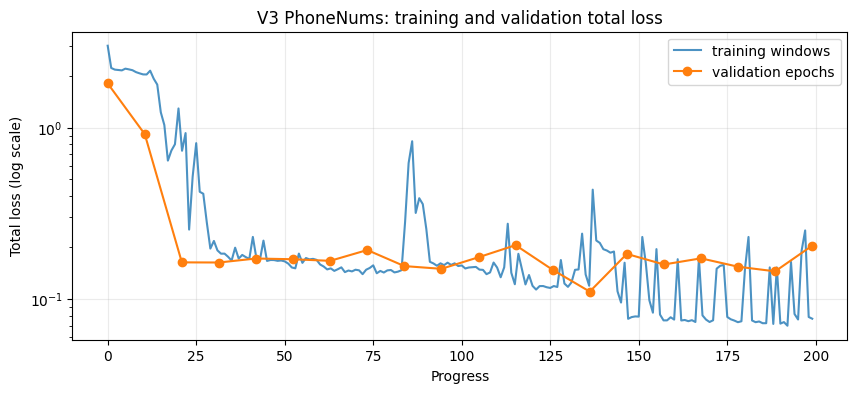

In [ ]:
import re, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/V3_reproduction/logs/phonenums_10k_20ep')
log_path = run_dir / 'log.txt'
checkpoints = sorted(run_dir.glob('cp_epoch*.pt'))
print('Checkpoints:', [p.name for p in checkpoints])
assert log_path.exists() and checkpoints, 'Training outputs are missing.'

text = log_path.read_text()
train = [(int(e), float(v)) for e, v in re.findall(r'TRAIN - Epoch \[(\d+)/\d+\].*?Loss: ([0-9.eE+-]+)', text)]
val = [(int(e), float(v)) for e, v in re.findall(r'VALIDATION - Epoch \[(\d+)/\d+\], Loss: ([0-9.eE+-]+)', text)]
assert train and val, 'Could not parse loss values from log.txt.'

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(train)), [v for _, v in train], label='training windows', alpha=.8)
plt.plot(np.linspace(0, len(train)-1, len(val)), [v for _, v in val], 'o-', label='validation epochs')
plt.yscale('log')
plt.xlabel('Progress')
plt.ylabel('Total loss (log scale)')
plt.title('V3 PhoneNums: training and validation total loss')
plt.grid(alpha=.25)
plt.legend();
print('Best validation entry:', min(val, key=lambda z: z[1]))
print('✅ Persistent training outputs confirmed')

## 7. Select the best retained checkpoint
The repository only retains a few checkpoints. This cell selects the retained checkpoint with the smallest logged validation loss.

In [ ]:
val_by_epoch = dict(val)
available = []
for p in checkpoints:
    epoch = int(re.search(r'cp_epoch(\d+)\.pt', p.name).group(1))
    if epoch in val_by_epoch:
        available.append((val_by_epoch[epoch], epoch, p))
assert available
best_val, best_epoch, best_checkpoint = min(available)
print('Best retained epoch:', best_epoch)
print('Validation loss:', best_val)
print('Checkpoint:', best_checkpoint)
print('✅ Best checkpoint selected')

Best retained epoch: 13
Validation loss: 0.1104
Checkpoint: /content/drive/MyDrive/V3_reproduction/logs/phonenums_10k_20ep/cp_epoch13.pt
✅ Best checkpoint selected


## 8. Measure individual V3 loss components on validation data
This does not change the model. It reports reconstruction, content, style, sample, fragment, and commitment losses separately.

In [ ]:
from collections import defaultdict
from model.v3_loss import V3Loss

val_loader = get_dataloader('/content/data/PhoneNums10k/val', batch_size=32, num_workers=2, n_fragments=10, fragment_len=32, shuffle=False)
model = get_model(cfg['dataloader'], cfg['model_config']).cuda()
checkpoint = torch.load(best_checkpoint, map_location='cuda')
model.load_state_dict(checkpoint['model'])
model.eval()
loss_fn = V3Loss(cfg['loss_config'])
totals, batches = defaultdict(float), 0

with torch.no_grad():
    for batch, _, _ in val_loader:
        batch = batch.cuda()
        out, zc, zcq, indices, commit, zs = model(batch)
        losses = loss_fn.compute_loss(out, zc, zcq, commit, zs, batch)
        for name, value in losses.items():
            totals[name] += float(value)
        batches += 1

averages = {k: v / batches for k, v in totals.items()}
for k, v in averages.items():
    print(f'{k:16s}: {v:.6f}')
print('✅ Individual validation losses measured')

recon_loss      : 0.110414
content_loss    : 0.000000
style_loss      : 0.000000
sample_loss     : 0.000000
fragment_loss   : 0.000000
commit_loss     : 0.000000
total_loss      : 0.110414
✅ Individual validation losses measured


In [ ]:
from pathlib import Path

root = Path('/content/data/PhoneNums10k')

train_files = {p.name for p in (root / 'train').glob('*.png')}
val_files = {p.name for p in (root / 'val').glob('*.png')}
test_files = {p.name for p in (root / 'test').glob('*.png')}

print('train:', len(train_files))
print('val:', len(val_files))
print('test:', len(test_files))

print('train ∩ val:', len(train_files & val_files))
print('train ∩ test:', len(train_files & test_files))
print('val ∩ test:', len(val_files & test_files))

assert not (train_files & val_files)
assert not (train_files & test_files)
assert not (val_files & test_files)

print('✅ No overlap between train, validation, and test sets')

train: 8000
val: 999
test: 999
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
✅ No overlap between train, validation, and test sets


In [ ]:
for name, value in averages.items():
    print(f'{name:16s}: {value:.12e}')

recon_loss      : 1.104137189686e-01
content_loss    : 0.000000000000e+00
style_loss      : 0.000000000000e+00
sample_loss     : 0.000000000000e+00
fragment_loss   : 0.000000000000e+00
commit_loss     : 0.000000000000e+00
total_loss      : 1.104137189686e-01


## 9. Run the official representation evaluation
This creates precision-recall metrics, t-SNE visualizations, and confusion matrices in the same Drive folder as the checkpoint.

In [ ]:
eval_cfg = dict(cfg)
eval_cfg['active_checkpoint'] = str(best_checkpoint)
eval_config_path = Path('/content/variance-versus-invariance/cfg_phonenums_10k_eval.yaml')
eval_config_path.write_text(yaml.safe_dump(eval_cfg, sort_keys=False))
print('Checkpoint for evaluation:', best_checkpoint)
!python run_evaluation.py --config cfg_phonenums_10k_eval.yaml --pr_metrics --vis_tsne --confusion_mtx


Checkpoint for evaluation: /content/drive/MyDrive/V3_reproduction/logs/phonenums_10k_20ep/cp_epoch13.pt
Content k_list: [1, 2, 5, 10, 20, 50, 75, 100, 200, 299, 399, 499, 500, 748, 998]
Style k_list: [1, 2, 3, 5, 7, 10, 13, 20, 27, 50, 67, 100, 101, 135, 200, 270, 405, 500, 540, 674, 1012, 1349]
Content F1 Range:  0.0013042072455088298 0.31661370690759116
Style F1 Range:  0.0011330596200219384 0.29013219304509585
Content AUC: 0.12182811410451633
Style AUC: 0.09460073359411084
Content F1 (Using Style Emb) Range:  0.00155791441599528 0.582032887379567
Style F1 (Using Content Emb) Range:  0.0005700355595177239 0.27151598009141953
Content AUC (Using Style Emb): 0.38925643158527723
Style AUC (Using Content Emb): 0.07720515169203564
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont

In [ ]:
import subprocess
import yaml
import re
from pathlib import Path

run_dir = Path(
    '/content/drive/MyDrive/V3_reproduction/logs/phonenums_10k_20ep'
)

results = []

for checkpoint in sorted(run_dir.glob('cp_epoch*.pt')):
    epoch = int(
        re.search(r'cp_epoch(\d+)\.pt', checkpoint.name).group(1)
    )

    checkpoint_cfg = dict(cfg)
    checkpoint_cfg['active_checkpoint'] = str(checkpoint)
    checkpoint_cfg['portion'] = 1.0

    config_path = Path(
        f'/content/variance-versus-invariance/'
        f'cfg_eval_epoch{epoch}.yaml'
    )

    config_path.write_text(
        yaml.safe_dump(checkpoint_cfg, sort_keys=False)
    )

    print(f'\n===== Evaluating epoch {epoch} =====')

    process = subprocess.run(
        [
            'python',
            'run_evaluation.py',
            '--config',
            str(config_path),
            '--pr_metrics',
        ],
        capture_output=True,
        text=True,
    )

    output = process.stdout
    print(output)

    def extract(pattern):
        match = re.search(pattern, output)
        return float(match.group(1)) if match else None

    results.append({
        'epoch': epoch,
        'content_auc': extract(r'Content AUC: ([0-9.eE+-]+)'),
        'style_auc': extract(r'Style AUC: ([0-9.eE+-]+)'),
        'content_from_style': extract(
            r'Content AUC \(Using Style Emb\): ([0-9.eE+-]+)'
        ),
        'style_from_content': extract(
            r'Style AUC \(Using Content Emb\): ([0-9.eE+-]+)'
        ),
    })

print('\n===== CHECKPOINT COMPARISON =====')
for result in results:
    print(result)


===== Evaluating epoch 12 =====
Content k_list: [1, 2, 5, 10, 20, 50, 75, 100, 200, 299, 399, 499, 500, 748, 998]
Style k_list: [1, 2, 3, 5, 7, 10, 13, 20, 27, 50, 67, 100, 101, 135, 200, 270, 405, 500, 540, 674, 1012, 1349]
Content F1 Range:  0.0006302599404547904 0.18533322140499875
Style F1 Range:  0.0007381356275594748 0.24611441428000266
Content AUC: 0.04145356455213311
Style AUC: 0.0628762290341384
Content F1 (Using Style Emb) Range:  0.0009026044004552954 0.24637434981368087
Style F1 (Using Content Emb) Range:  0.000510565603936876 0.22326802510518332
Content AUC (Using Style Emb): 0.08580535723203468
Style AUC (Using Content Emb): 0.052646078563080095


===== Evaluating epoch 13 =====
Content k_list: [1, 2, 5, 10, 20, 50, 75, 100, 200, 299, 399, 499, 500, 748, 998]
Style k_list: [1, 2, 3, 5, 7, 10, 13, 20, 27, 50, 67, 100, 101, 135, 200, 270, 405, 500, 540, 674, 1012, 1349]
Content F1 Range:  0.0013042072455088298 0.31661370690759116
Style F1 Range:  0.0011330596200219384 0.29

In [ ]:
from pathlib import Path
from datetime import datetime
import hashlib
import json
import shutil

source_dir = Path(
    "/content/drive/MyDrive/V3_reproduction/logs/phonenums_10k_20ep"
)

archive_root = Path(
    "/content/drive/MyDrive/V3_reproduction/archived_runs"
)

run_name = "Run_A_PhoneNums10k_20ep_repo_defaults"
archive_dir = archive_root / run_name

assert source_dir.exists(), f"Source directory not found: {source_dir}"
assert not archive_dir.exists(), (
    f"Archive already exists: {archive_dir}\n"
    "Nothing was overwritten."
)

archive_root.mkdir(parents=True, exist_ok=True)
shutil.copytree(source_dir, archive_dir)

summary = {
    "run_id": "Run_A",
    "name": run_name,
    "archived_at": datetime.now().isoformat(),
    "dataset": {
        "name": "PhoneNums",
        "generated_attempts": 10000,
        "unique_samples": 9998,
        "train": 8000,
        "validation": 999,
        "test": 999,
    },
    "training": {
        "epochs": 20,
        "batch_size": 32,
        "best_reconstruction_epoch": 13,
        "best_validation_loss": 0.110414,
    },
    "evaluation": {
        "evaluation_set": "full test set",
        "epoch_12": {
            "content_auc": 0.04145356455213311,
            "style_auc": 0.0628762290341384,
            "content_from_style": 0.08580535723203468,
            "style_from_content": 0.052646078563080095,
        },
        "epoch_13": {
            "content_auc": 0.12182811410451633,
            "style_auc": 0.09460073359411084,
            "content_from_style": 0.38925643158527723,
            "style_from_content": 0.07720515169203564,
        },
        "epoch_18": {
            "content_auc": 0.1057868728462075,
            "style_auc": 0.08199502006290038,
            "content_from_style": 0.6234740035206439,
            "style_from_content": 0.07827369681936669,
        },
        "epoch_19": {
            "content_auc": 0.1224444164529831,
            "style_auc": 0.07874092857338666,
            "content_from_style": 0.632561331121268,
            "style_from_content": 0.07505319728195986,
        },
    },
    "conclusion": (
        "Engineering reproduction completed and reconstruction converged, "
        "but semantic disentanglement was not reproduced. "
        "Content leakage into the style representation increased in later epochs."
    ),
    "status": "ARCHIVED_DO_NOT_OVERWRITE",
}

summary_path = archive_dir / "RUN_SUMMARY.json"
summary_path.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

manifest = {}
for file_path in sorted(archive_dir.rglob("*")):
    if file_path.is_file() and file_path.name != "SHA256SUMS.json":
        digest = hashlib.sha256(file_path.read_bytes()).hexdigest()
        manifest[str(file_path.relative_to(archive_dir))] = digest

manifest_path = archive_dir / "SHA256SUMS.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("✅ Run A archived successfully")
print("Archive:", archive_dir)
print("Files recorded:", len(manifest))
print("Summary:", summary_path)
print("Checksums:", manifest_path)



✅ Run A archived successfully
Archive: /content/drive/MyDrive/V3_reproduction/archived_runs/Run_A_PhoneNums10k_20ep_repo_defaults
Files recorded: 12
Summary: /content/drive/MyDrive/V3_reproduction/archived_runs/Run_A_PhoneNums10k_20ep_repo_defaults/RUN_SUMMARY.json
Checksums: /content/drive/MyDrive/V3_reproduction/archived_runs/Run_A_PhoneNums10k_20ep_repo_defaults/SHA256SUMS.json


## 10. List all saved outputs

In [ ]:
for p in sorted(run_dir.rglob('*')):
    if p.is_file():
        print(p.relative_to(run_dir), round(p.stat().st_size / 1024**2, 2), 'MB')
print('✅ STAGE 2 COMPLETE')